# **===========================================================================================================================================================** #
# **Machine Learning: Unit 2 End Project** #
# **===========================================================================================================================================================** #

## <u>**Notebook Setup**</u> ##

In [4]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.base import (
    BaseEstimator, 
    TransformerMixin
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering, 
    FeatureAgglomeration,
    DBSCAN
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)

from scipy.stats import t
from scipy.stats import (
    boxcox, 
    yeojohnson, 
    shapiro
)

from scipy.cluster.hierarchy import (
    dendrogram, 
    linkage
)

import scipy.sparse as sp
from scipy.sparse.linalg import svds

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)

from sklearn.decomposition import (
    PCA,
    TruncatedSVD,
    NMF
)

from sklearn.manifold import TSNE

from statsmodels.nonparametric.smoothers_lowess import lowess

from kneed import KneeLocator

### **Initial Data Load** ###

In [ ]:
# Import data into DataFrame
# Renamed CSV file is assumed to live in same folder as my notebook
df_employeeTurnover = pd.read_csv("HR_comma_sep.csv")

# Make a copy of the dataframe to save dataframe pre-modificiations
# Keep the original unmodified data for reference purposes.
df_employeeTurnover_initial = df_employeeTurnover.copy(deep=True)

# Create a globel name for the data set
data_set_name = 'Employee Turnover'


### **EDA Utility Functions** ###

In [6]:
data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

## <u>**1. Data Import and Initial Exploratory Data Analysis**</u> ##


***********************************
Description Stats
***********************************

                 Feature    count unique    top  freq        mean        std  \
0     satisfaction_level  14999.0    NaN    NaN   NaN    0.612834   0.248631   
1        last_evaluation  14999.0    NaN    NaN   NaN    0.716102   0.171169   
2         number_project  14999.0    NaN    NaN   NaN    3.803054   1.232592   
3   average_montly_hours  14999.0    NaN    NaN   NaN  201.050337  49.943099   
4     time_spend_company  14999.0    NaN    NaN   NaN    3.498233   1.460136   
5          Work_accident  14999.0    NaN    NaN   NaN     0.14461   0.351719   
6                   left  14999.0    NaN    NaN   NaN    0.238083   0.425924   
7  promotion_last_5years  14999.0    NaN    NaN   NaN    0.021268   0.144281   
8                  sales    14999     10  sales  4140         NaN        NaN   
9                 salary    14999      3    low  7316         NaN        NaN   

    min    25%    50%    75

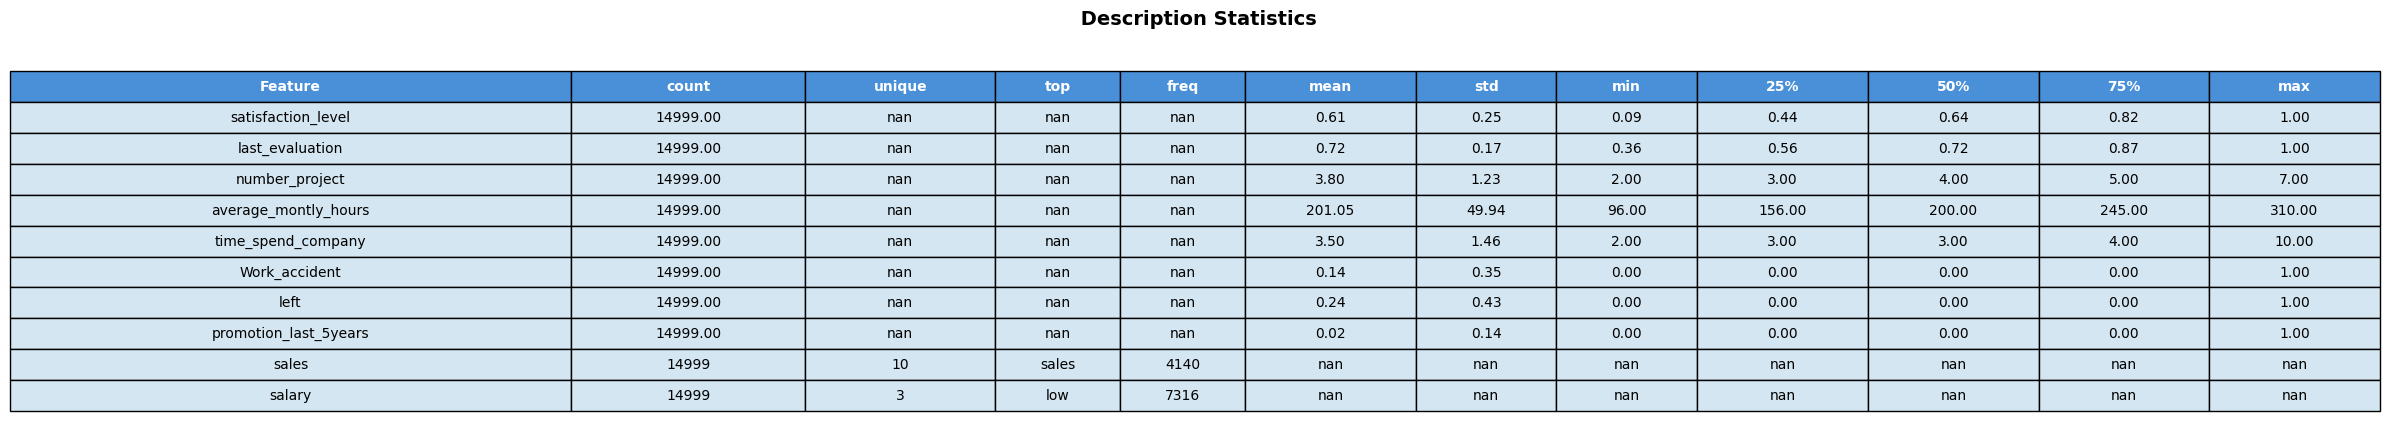

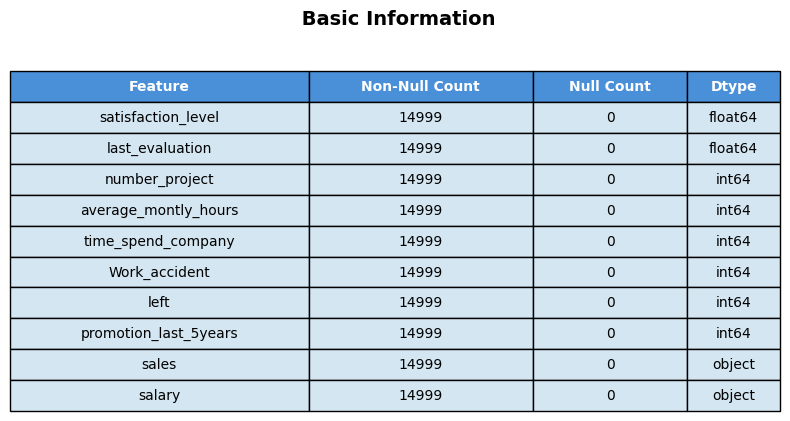

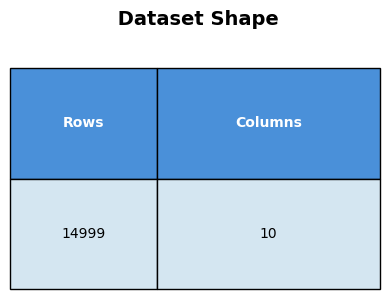




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



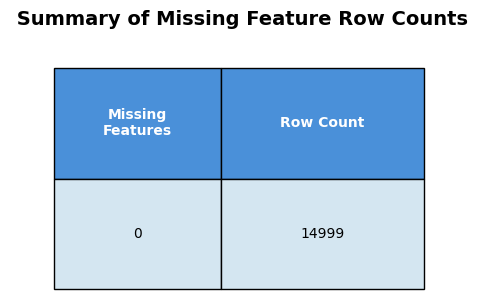

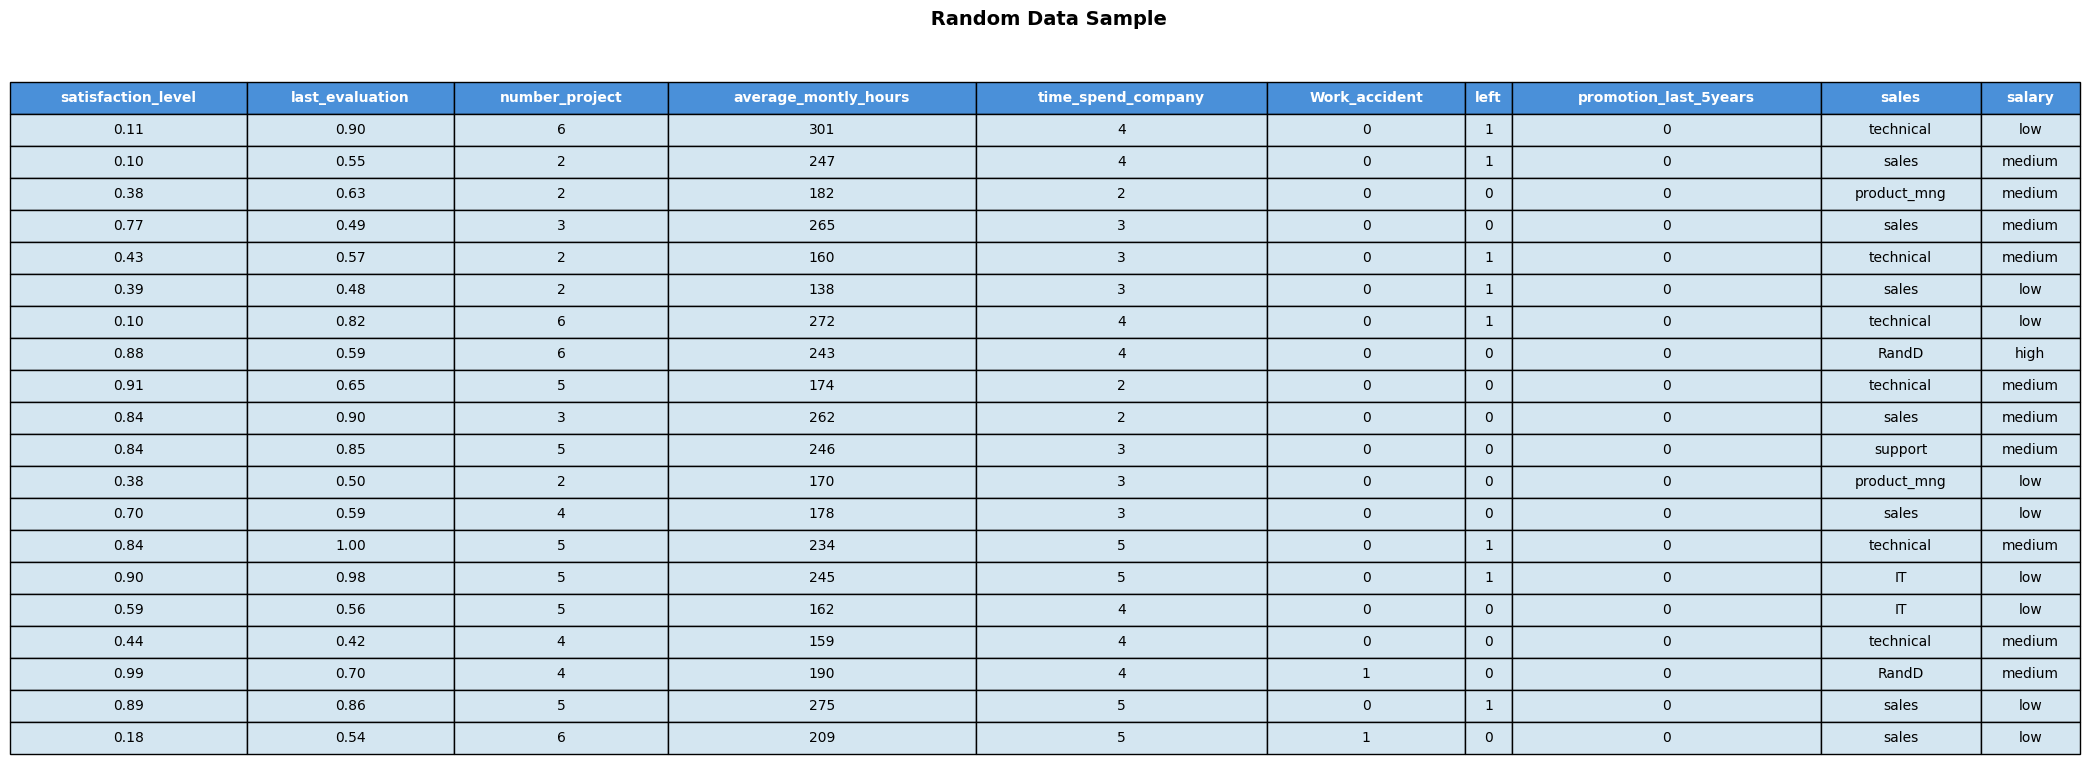

In [7]:
# print out the dataframes stats
print(data_set_name)
PrintDataFrameStatistics(df_employeeTurnover)

### **Initial EDA Analysis** ###
    - Movie Data - 14999 rows of data, 10 features (columns)
    - No rows of missing or (nan) data in either dataset
    - Need to leading/following trim() categorical feature columns

### **Missing Values and Imputation** ###
Not required

##### **Trim Categorical Features** #####

In [ ]:
obj_cols = df_employeeTurnover.select_dtypes(include='object').columns
df_employeeTurnover[obj_cols] = df_employeeTurnover[obj_cols].apply(lambda col: col.str.strip())